In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/creditcard.csv")

In [2]:
X = df.drop(columns=["Class"])
y = df["Class"]            

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y)

In [5]:
y_train.mean()

np.float64(0.001729245759178389)

In [6]:
y_test.mean()

np.float64(0.0017204452090867595)

In [7]:
from sklearn.linear_model import LogisticRegression

In [8]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)
previsoes = modelo.predict(X_test)

/home/ixcsoft/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, previsoes)

0.9992451107756047

In [10]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, previsoes)

array([[56852,    12],
       [   31,    67]])

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.68      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.84      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
modelo2 = LogisticRegression(max_iter=1000, class_weight="balanced")

In [13]:
modelo2.fit(X_train, y_train)
previsoes = modelo2.predict(X_test)

/home/ixcsoft/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, previsoes)

array([[55360,  1504],
       [    8,    90]])

In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [16]:
probs = modelo2.predict_proba(X_test)[:, 1]
previsoes_09 = (probs > 0.9).astype(int)

In [17]:
print(classification_report(y_test, previsoes_09))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.22      0.89      0.35        98

    accuracy                           0.99     56962
   macro avg       0.61      0.94      0.68     56962
weighted avg       1.00      0.99      1.00     56962



In [18]:
previsoes_099 = (probs > 0.99).astype(int)
print(classification_report(y_test, previsoes_099))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.85      0.69        98

    accuracy                           1.00     56962
   macro avg       0.79      0.92      0.85     56962
weighted avg       1.00      1.00      1.00     56962



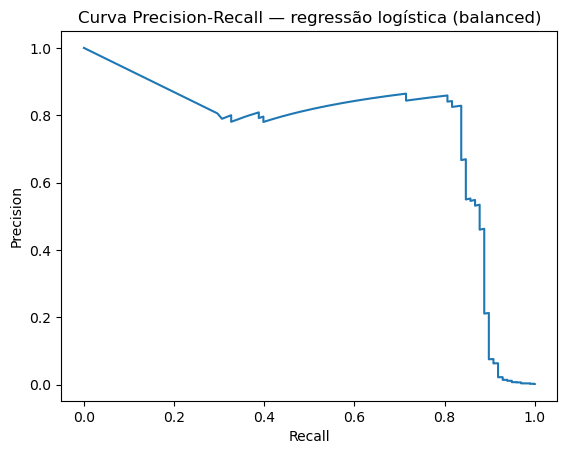

In [19]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — regressão logística (balanced)")
plt.show()